# Kasatria Data Scientist Assignment – Python Analysis

This notebook contains the Python-based statistical analysis for the Kasatria Data Scientist preliminary assignment.

## Analysis Covered
- Data validation and quality checks
- Age vs income analysis for Diploma holders
- Pearson correlation
- Linear regression
- R² evaluation
- Salary prediction for a 40-year-old Diploma holder
- Data visualization


In [17]:
import pandas as pd

df = pd.read_csv("kasatria_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (21, 20)


,Subject ID,Name,Age,Gender,Annual Income,Monthly Income,Education,Education Rank,Phone Owned,Brand,Is Phone?,High Earner (RM5k+/mth)?,Email,Web,Mobile,Walk-In,Video Call,Phone Call,Letter,Channels Selected
0,1.0,Ali,22.0,M,"15,000",1250.00,Highschool,2.0,Samsung Galaxy S3,Samsung,Yes,No,1.0,1.0,1.0,1.0,0.0,0.0,0.0,4.0
1,2.0,Mutu,25.0,M,"30,000",2500.00,Diploma,3.0,HTC One Note,HTC,Yes,No,1.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0
2,3.0,Lim,33.0,M,"36,000",3000.00,Diploma,3.0,iPhone 5,Apple,Yes,No,1.0,1.0,1.0,0.0,1.0,0.0,0.0,4.0
3,4.0,Angie,47.0,F,"45,000",3750.00,Diploma,3.0,iPhone 6s,Apple,Yes,No,1.0,0.0,0.0,1.0,1.0,1.0,1.0,5.0
4,5.0,Jack,26.0,M,"25,000",2083.33,Degree,4.0,Xiaomi MI3,Xiaomi,Yes,No,1.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0


In [18]:
# Remove completely empty rows
df = df.dropna(how="all")

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (20, 20)


In [19]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values by column:
Subject ID                  0
Name                        0
Age                         0
Gender                      0
Annual Income               0
Monthly Income              0
Education                   0
Education Rank              0
Phone Owned                 0
Brand                       0
Is Phone?                   0
High Earner (RM5k+/mth)?    0
Email                       0
Web                         0
Mobile                      0
Walk-In                     0
Video Call                  0
Phone Call                  0
Letter                      0
Channels Selected           0
dtype: int64

Duplicate rows: 0


In [20]:
# Filter only Diploma holders
diploma = df[df["Education"] == "Diploma"].copy()

# Convert Annual Income to numeric because the CSV contains commas
diploma["Annual Income"] = (
    diploma["Annual Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Show the relevant data
diploma[["Name", "Age", "Annual Income"]]

,Name,Age,Annual Income
1,Mutu,25.0,30000.0
2,Lim,33.0,36000.0
3,Angie,47.0,45000.0
11,Trevor,25.0,30000.0
12,Melinda,39.0,33000.0
13,Aishah,45.0,42000.0


In [21]:
# Correlation between age and annual income
correlation = diploma["Age"].corr(diploma["Annual Income"])

print("Correlation between Age and Annual Income:", round(correlation, 4))

Correlation between Age and Annual Income: 0.9132


In [22]:
from sklearn.linear_model import LinearRegression

# Predictor: Age
X = diploma[["Age"]]

# Target: Annual Income
y = diploma["Annual Income"]

# Create and fit the regression model
model = LinearRegression()
model.fit(X, y)

# Regression values
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print("Slope:", round(slope, 2))
print("Intercept:", round(intercept, 2))
print("R-squared:", round(r_squared, 4))

Slope: 598.27
Intercept: 14661.85
R-squared: 0.8339


In [23]:
# Predict annual income for a 40-year-old Diploma holder
predicted_annual = model.predict(pd.DataFrame({"Age": [40]}))[0]
predicted_monthly = predicted_annual / 12

print("Predicted annual income at age 40: RM", round(predicted_annual, 2))
print("Predicted monthly income at age 40: RM", round(predicted_monthly, 2))

Predicted annual income at age 40: RM 38592.49
Predicted monthly income at age 40: RM 3216.04


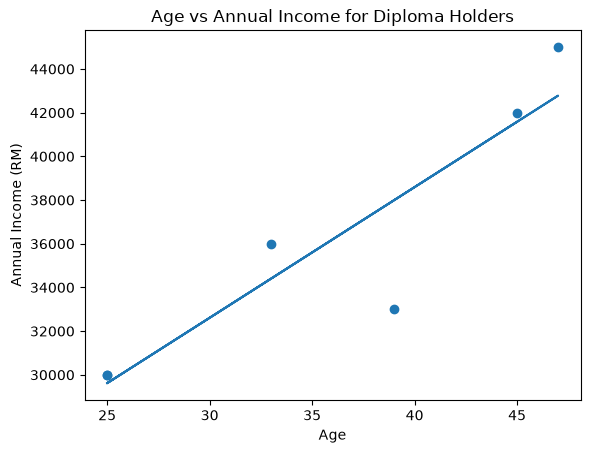

In [24]:
import matplotlib.pyplot as plt

# Scatter plot of actual Diploma-holder data
plt.scatter(diploma["Age"], diploma["Annual Income"])

# Regression line
plt.plot(diploma["Age"], model.predict(X))

plt.xlabel("Age")
plt.ylabel("Annual Income (RM)")
plt.title("Age vs Annual Income for Diploma Holders")

plt.show()

In [25]:
print("Q3 Summary")
print("Correlation:", round(correlation, 4))
print("R-squared:", round(r_squared, 4))
print("Slope:", round(slope, 2))

print("\nQ4 Summary")
print("Predicted annual income at age 40: RM", round(predicted_annual, 2))
print("Predicted monthly income at age 40: RM", round(predicted_monthly, 2))

Q3 Summary
Correlation: 0.9132
R-squared: 0.8339
Slope: 598.27

Q4 Summary
Predicted annual income at age 40: RM 38592.49
Predicted monthly income at age 40: RM 3216.04
